# Week 15 — Geometry-aware neural operators for separated step flow
## Geo-DeepONet, FNO and U-FNO: from global accuracy to physical diagnostics

**FlowMLLab · Week 15 · Ehsan Roohi's retained research outputs**

This executable CPU lab audits **nine saved predictions**, not nine newly trained models:
three architectures × Re = 25, 50, 100, one geometry (`g011`), one seed (17).
The reference is the CFD field stored alongside each prediction, **not DSMC**.
This continuum study is distinct from the rarefied micro-step data in Lab 1.

The companion `dataset.npz` contains the actual 130 accepted, sampled OpenFOAM
fields used by this historical run: 106 training cases, 21 validation cases and
3 test cases, grouped by whole geometry. The notebook verifies its recorded hash,
inspects every array, reconstructs a case manifest and visualizes all three splits.

Learning outcomes: check geometry-level splits; compare velocity and pressure fairly;
differentiate velocity without crossing solid boundaries; distinguish reverse-flow
footprints from vortex identification; and design a defensible next experiment.

**Execution boundary.** Training/validation/test fields are included, but checkpoints,
the original training source and complete OpenFOAM case directories are not. Running
all cells re-computes data audits, metrics and figures from actual retained fields.
It does not retrain the networks or independently validate the CFD solver.
The historical test geometry has since been inspected repeatedly: it is now a
development example, not an unopened final test.

### Run
Use a complete repository checkout with Python 3.10+ and `numpy`, `pandas`,
`matplotlib`, `scipy`, `nbformat`, and `ipykernel`. The full lab also reads the
geometry-holdout and DSMC V5 directories: uploading only two archives is insufficient.
In Colab, clone the repository and change into it before running this notebook.
No paid GPU is needed.

[Open in Colab](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week15/W15_Geometry_Operators_Step_Audit.ipynb)

In [1]:
%matplotlib inline
from pathlib import Path
import io, json, tarfile, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion
from IPython.display import display

EXPECTED_SHA = '190bb252c2739fc2acfa0841233652144b82eb9ca3a01ad6ddb2ae0f0429ade1'
EXPECTED_DATASET_SHA = '28d4d4c440cdc4c1ac1d13749ce00b0690d99f29cf20fd56c65fc00b6a8058fd'
roots = [Path.cwd(), *Path.cwd().parents]
candidates = [p / 'results/step_operator_audit/wake_predictions.tgz' for p in roots]
candidates += [Path.cwd() / 'wake_predictions.tgz']
ARCHIVE = next((p for p in candidates if p.is_file()), None)
if ARCHIVE is None:
    raise FileNotFoundError('Upload wake_predictions.tgz next to the notebook, then rerun.')
assert hashlib.sha256(ARCHIVE.read_bytes()).hexdigest() == EXPECTED_SHA, 'Wrong archive version'
data_candidates = [p / 'results/step_operator_audit/source/dataset.npz' for p in roots]
data_candidates += [Path.cwd() / 'dataset.npz']
DATASET = next((p for p in data_candidates if p.is_file()), None)
if DATASET is None:
    raise FileNotFoundError('Upload dataset.npz next to the notebook, then rerun.')
assert hashlib.sha256(DATASET.read_bytes()).hexdigest() == EXPECTED_DATASET_SHA, 'Wrong dataset version'
OUT = ARCHIVE.parent / 'generated'
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10, 'axes.titlesize': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Verified archive:', ARCHIVE.name)
print('Verified OpenFOAM dataset:', DATASET.name)
print('Python:', platform.python_version(), '| NumPy:', np.__version__)

Verified archive: wake_predictions.tgz
Verified OpenFOAM dataset: dataset.npz
Python: 3.12.14 | NumPy: 2.5.3


## 1. What do the three models represent?

| Model label in archive | Conceptual learning mechanism | Key diagnostic question |
|---|---|---|
| Geo-DeepONet (`geom`) | Geometry-conditioned branch/trunk operator representation | Does geometry conditioning preserve local separation? |
| FNO (`fno`) | Learned spectral mixing of grid-based feature fields | Does global spectral accuracy hide local boundary errors? |
| U-FNO (`ufno`) | Fourier operator augmented by a local U-shaped pathway | Does local processing improve the wake, pressure, or neither? |

These are conceptual descriptions, **not an audited reconstruction of the exact
training architectures**. The archive records a training-code hash, but contains no
source to verify layers, parameter counts or conditioning implementation.
Do not replace those missing details with a newly invented network.

The source records 400 training epochs, seed 17, near-SDF weight 4 and reverse-flow
weight 12. Verify these values below rather than importing a later experiment's setup.
All three Reynolds numbers of the test geometry must stay outside training and selection.

In [2]:
MODELS = ['geom', 'fno', 'ufno']
LABELS = {'geom':'Geo-DeepONet', 'fno':'FNO', 'ufno':'U-FNO'}
RES = [25, 50, 100]
fields, reports, manifest = {}, {}, {}
# Read members in memory; do not extract untrusted paths to the filesystem.
with tarfile.open(ARCHIVE, 'r:gz') as tar:
    for model in MODELS:
        prefix = f'wake_focused/{model}/seed_17/'
        raw = tar.extractfile(prefix + 'metrics.json').read()
        reports[model] = json.loads(raw)
        manifest[prefix+'metrics.json'] = hashlib.sha256(raw).hexdigest()
        for re in RES:
            name = prefix + f'g011_Re{re}_medium_prediction.npz'
            raw = tar.extractfile(name).read()
            manifest[name] = hashlib.sha256(raw).hexdigest()
            with np.load(io.BytesIO(raw), allow_pickle=False) as z:
                fields[model, re] = {key:z[key].copy() for key in z.files}

for model, report in reports.items():
    splits = [set(report['geometry_ids'][k]) for k in ['train','validation','test']]
    assert all(not (splits[i] & splits[j]) for i in range(3) for j in range(i))
    assert splits[2] == {11} and report['seed'] == 17
    assert report['protocol'] == 'wake_focused_geometry_holdout'
    for re in RES:
        f = fields[model,re]
        assert f['prediction'].shape == f['truth'].shape == (18000,3)
        assert f['mask'].dtype == bool and f['mask'].sum() > 0
        assert np.isfinite(f['prediction']).all() and np.isfinite(f['truth']).all()
        for key in ['truth','coordinates','mask','shape']:
            np.testing.assert_array_equal(f[key], fields['geom',re][key])

display(pd.DataFrame([{'model':LABELS[m], 'seed':r['seed'], 'epochs':r['epochs'],
    'best_epoch':r['best_epoch'], 'target':str(r['target']),
    'pressure_transform':r.get('pressure_transform'),
    'loss_weights':str(r.get('loss_weights'))} for m,r in reports.items()]))
(OUT / 'source_manifest.json').write_text(json.dumps({'archive_sha256':EXPECTED_SHA,
    'members':manifest,'reports':reports}, indent=2), encoding='utf-8')
print('All nine fields are finite; reference fields match across models; recorded splits are disjoint.')

,model,seed,epochs,best_epoch,target,pressure_transform,loss_weights
0,Geo-DeepONet,17,400,316,"['u', 'v', 'Re*p_kinematic']",p_star=Re_in*p,"{'near_sdf': 4.0, 'reverse_u': 12.0}"
1,FNO,17,400,321,"['u', 'v', 'Re*p_kinematic']",p_star=Re_in*p,"{'near_sdf': 4.0, 'reverse_u': 12.0}"
2,U-FNO,17,400,391,"['u', 'v', 'p_kinematic']",none,"{'near_sdf': 4.0, 'reverse_u': 12.0}"


All nine fields are finite; reference fields match across models; recorded splits are disjoint.


## 2. Audit the actual OpenFOAM training, validation and test fields

`dataset.npz` stores 130 accepted fields on the common 60×300 sampling grid.
`raw[...,0:3]` are $u$, $v$ and the stored pressure target; `queries` contain
normalized $x$, $y$ and signed distance to the obstacle; `masks` identify fluid.
The saved training metadata names the pressure target as $p^*=Re\,p$.

The dataset does not contain a geometry-ID column. We therefore assign IDs by the
first occurrence of each unique geometry mask, matching the source's sorted case order.
This reconstruction is checked directly for `g011`: all three fields, masks and
coordinates are bit-for-bit identical to the references in the prediction archive.
The mapping for the other IDs remains an auditable inference until the original source
or an explicit case-name manifest is recovered.

In [3]:
with np.load(DATASET, allow_pickle=False) as z:
    dataset = {k:z[k].copy() for k in z.files}
assert set(dataset) == {'raw','queries','masks','Re','shape'}
assert tuple(dataset['shape']) == (60,300)
assert dataset['raw'].shape == dataset['queries'].shape == (130,18000,3)
assert dataset['masks'].shape == (130,18000) and dataset['masks'].dtype == bool
assert dataset['Re'].shape == (130,) and set(dataset['Re']) == {25,50,100}
assert np.isfinite(dataset['raw']).all() and np.isfinite(dataset['queries']).all()

# Stable fingerprints identify geometry without trusting file names.
fingerprints = [hashlib.sha256(np.packbits(m).tobytes()).hexdigest() for m in dataset['masks']]
geometry_order = list(dict.fromkeys(fingerprints))
geometry_ids = np.array([geometry_order.index(h)+1 for h in fingerprints])
assert len(geometry_order) == 51

source_splits = {k:set(reports['geom']['geometry_ids'][k]) for k in ['train','validation','test']}
split_name = np.array([next(k for k,v in source_splits.items() if int(g) in v) for g in geometry_ids])
assert [int((split_name==k).sum()) for k in ['train','validation','test']] == [106,21,3]
assert [len(set(geometry_ids[split_name==k])) for k in ['train','validation','test']] == [41,9,1]

# Direct identity check anchors inferred group 11 to recorded g011.
for i in np.where(geometry_ids==11)[0]:
    re = int(dataset['Re'][i]); retained = fields['geom',re]
    np.testing.assert_array_equal(dataset['raw'][i],retained['truth'])
    np.testing.assert_array_equal(dataset['masks'][i],retained['mask'])
    np.testing.assert_allclose(dataset['queries'][i,:,:2],retained['coordinates']/[5,1],rtol=0,atol=0)

case_manifest = pd.DataFrame({'case_index':np.arange(130),'geometry_id_inferred':geometry_ids,
    'Re':dataset['Re'],'split':split_name,'fluid_cells':dataset['masks'].sum(axis=1),
    'geometry_mask_sha256':fingerprints})
case_manifest.to_csv(OUT/'dataset_case_manifest.csv',index=False)
coverage = case_manifest.groupby(['split','Re']).size().unstack(fill_value=0).reindex(['train','validation','test'])
display(coverage.assign(total=coverage.sum(axis=1)))
print('PASS: 130 finite sampled OpenFOAM fields; 51 masks; split counts 106/21/3; g011 identity verified.')

Re,25,50,100,total
split,,,,
train,32,40,34,106
validation,7,8,6,21
test,1,1,1,3


PASS: 130 finite sampled OpenFOAM fields; 51 masks; split counts 106/21/3; g011 identity verified.


### Split map and representative fields

The split map below is deliberately **not a bar chart**. Each square is one accepted
OpenFOAM case; rows are geometry identities and columns are Reynolds numbers. The
field panels use one Re=50 case from each split and plot the actual sampled OpenFOAM
speed and stored pressure target. No predicted field or synthetic replacement is used.

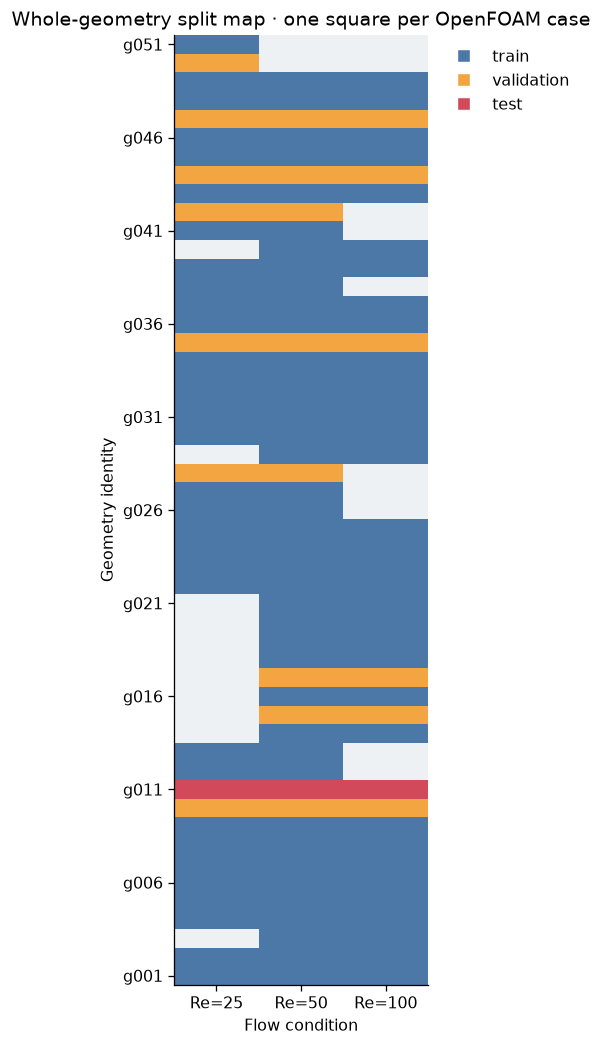

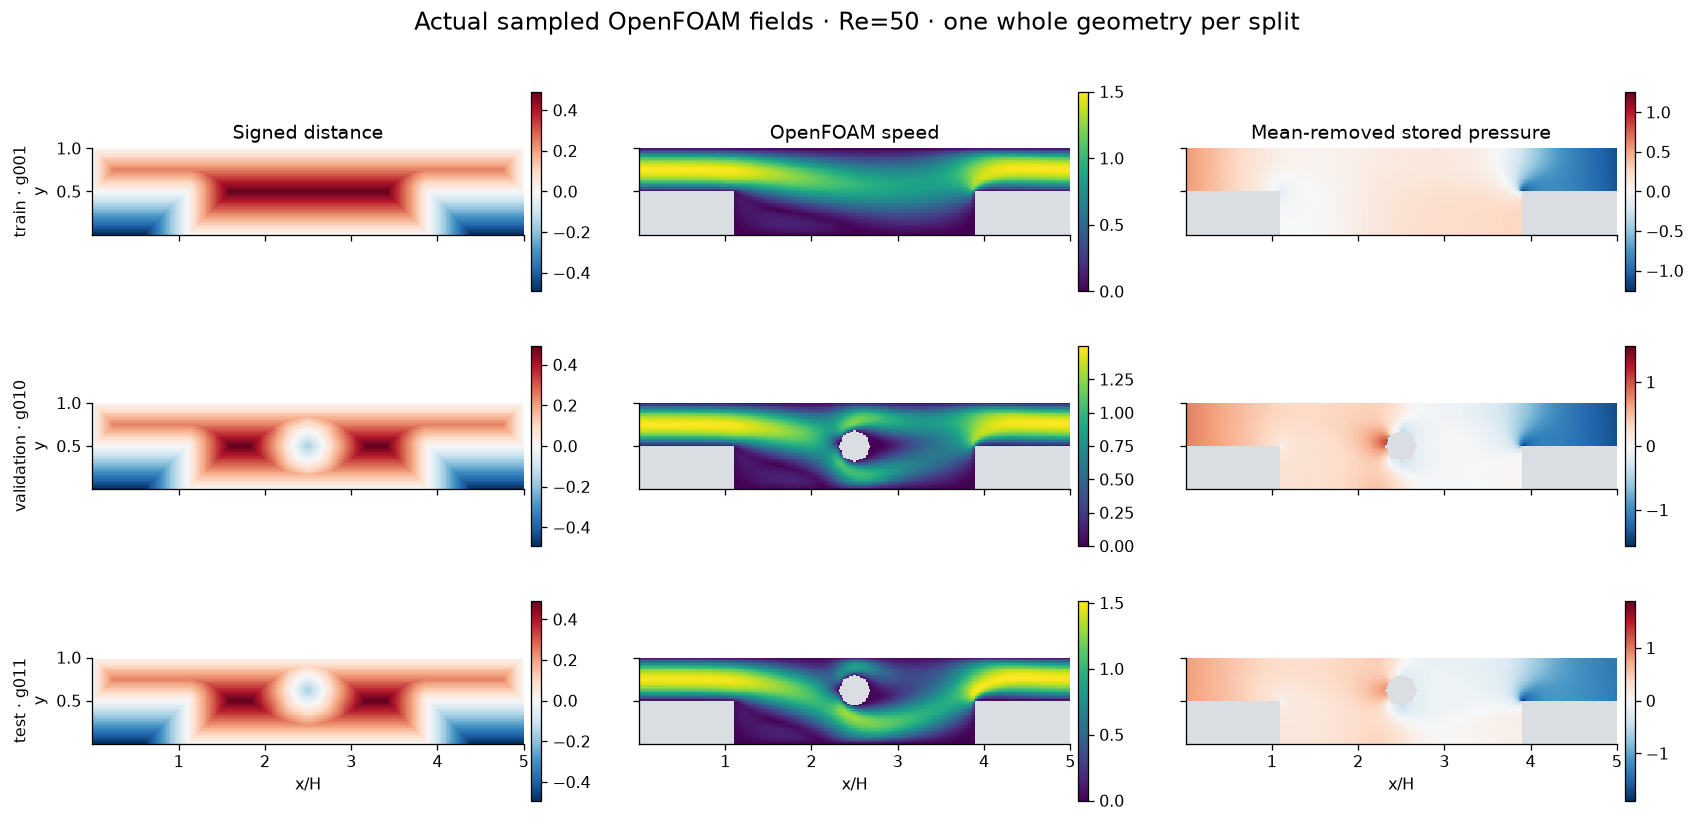

In [4]:
split_code={'train':0,'validation':1,'test':2}
split_grid=np.full((51,3),np.nan)
for row in case_manifest.itertuples():
    split_grid[int(row.geometry_id_inferred)-1,RES.index(int(row.Re))]=split_code[row.split]
from matplotlib.colors import ListedColormap, BoundaryNorm
fig,ax=plt.subplots(figsize=(6.4,9.2))
cmap=ListedColormap(['#4c78a8','#f2a541','#d1495b']); cmap.set_bad('#eef1f4')
ax.imshow(split_grid,origin='lower',aspect='.22',cmap=cmap,norm=BoundaryNorm([-.5,.5,1.5,2.5],3))
ax.set(xticks=range(3),xticklabels=[f'Re={r}' for r in RES],
       yticks=np.arange(0,51,5),yticklabels=[f'g{i:03d}' for i in range(1,52,5)],
       xlabel='Flow condition',ylabel='Geometry identity',title='Whole-geometry split map · one square per OpenFOAM case')
handles=[plt.Line2D([],[],marker='s',linestyle='',color=c,label=k) for k,c in
         zip(['train','validation','test'],['#4c78a8','#f2a541','#d1495b'])]
ax.legend(handles=handles,loc='upper left',bbox_to_anchor=(1.02,1),frameon=False)
fig.tight_layout(); fig.savefig(OUT/'dataset_split_matrix.png',dpi=150,bbox_inches='tight'); plt.show()

selected=[]
for sp in ['train','validation','test']:
    idx=int(case_manifest.index[(case_manifest.split==sp)&(case_manifest.Re==50)][0]); selected.append((sp,idx))
fig,axs=plt.subplots(3,3,figsize=(15,7.5),sharex=True,sharey=True)
for row,(sp,idx) in enumerate(selected):
    ny,nx=map(int,dataset['shape']); q=dataset['queries'][idx].reshape(ny,nx,3)
    a=dataset['raw'][idx].reshape(ny,nx,3); mask=dataset['masks'][idx].reshape(ny,nx)
    x=5*q[0,:,0]; y=q[:,0,1]
    vals=[q[:,:,2],np.ma.masked_where(~mask,np.hypot(a[:,:,0],a[:,:,1])),
          np.ma.masked_where(~mask,a[:,:,2]-a[:,:,2][mask].mean())]
    titles=['Signed distance','OpenFOAM speed','Mean-removed stored pressure']
    for col,(val,title) in enumerate(zip(vals,titles)):
        cm=plt.get_cmap('viridis' if col==1 else 'RdBu_r').copy(); cm.set_bad('#dadde2')
        lim=float(np.max(np.abs(val)))
        im=axs[row,col].pcolormesh(x,y,val,shading='nearest',cmap=cm,
            vmin=0 if col==1 else -lim,vmax=lim)
        axs[row,col].set_aspect('equal'); axs[row,col].set_facecolor('#dadde2')
        if row==0: axs[row,col].set_title(title)
        if col==0: axs[row,col].set_ylabel(f'{sp} · g{geometry_ids[idx]:03d}\ny')
        if row==2: axs[row,col].set_xlabel('x/H')
        fig.colorbar(im,ax=axs[row,col],shrink=.72,pad=.015)
fig.suptitle('Actual sampled OpenFOAM fields · Re=50 · one whole geometry per split',fontsize=15)
fig.tight_layout(); fig.savefig(OUT/'dataset_split_examples.png',dpi=150,bbox_inches='tight'); plt.show()

## 3. Metrics with explicit physical meaning

For fluid cells $M$, joint velocity error is
$100\|[\hat u-u,\hat v-v]_M\|_2/\|[u,v]_M\|_2$.
We report both raw-pressure relative error and shape error after **independent
mean removal** from reference and prediction. The latter discards pressure offset;
it is not a correction to the original prediction or evidence the outlet gauge was wrong.
A small pressure-fluctuation denominator can produce a large relative percentage.

The pressure column is evaluated as stored. The metadata describes the training
transform $p^*=Re\,p$; it does not unambiguously specify whether stored arrays have
already been inverse-transformed. Per-case relative errors and mean-removal errors
are invariant to a common nonzero scaling, so no guessed conversion is needed.
Absolute pressure units and pooled errors across Reynolds numbers are not inferred.

Reverse-flow IoU compares sets $u<0$ over fluid cells. It does **not** count vortices,
locate their centers, or measure wall-shear reattachment. Vorticity is
$\omega=\partial v/\partial x-\partial u/\partial y$; evaluate it only where the
finite-difference stencil remains entirely in fluid.

In [5]:
def relative(pred, truth):
    denom = np.linalg.norm(truth)
    return float(100*np.linalg.norm(pred-truth)/denom) if denom > 1e-12 else np.nan

def grid(f):
    ny,nx = map(int, f['shape'])
    xy = f['coordinates'].reshape(ny,nx,2)
    x,y = xy[0,:,0],xy[:,0,1]
    assert np.all(np.diff(x)>0) and np.all(np.diff(y)>0)
    np.testing.assert_allclose(xy[:,:,0], np.broadcast_to(x, (ny,nx)))
    np.testing.assert_allclose(xy[:,:,1], np.broadcast_to(y[:,None], (ny,nx)))
    return x,y,f['mask'].reshape(ny,nx)

def curl(a,x,y):
    return np.gradient(a[:,:,1],x,axis=1,edge_order=2)-np.gradient(a[:,:,0],y,axis=0,edge_order=2)

def diagnostics(f):
    x,y,mask = grid(f)
    truth,pred = (f[k].astype(float) for k in ['truth','prediction'])
    t,p = truth[mask.ravel()],pred[mask.ravel()]
    t0,p0 = t[:,2]-t[:,2].mean(),p[:,2]-p[:,2].mean()
    rt,rp = t[:,0]<0,p[:,0]<0
    union = (rt|rp).sum()
    interior = binary_erosion(mask, structure=np.ones((3,3)), border_value=0)
    wt,wp = [curl(a.reshape(*mask.shape,3),x,y) for a in [truth,pred]]
    return {'velocity_L2_pct':relative(p[:,:2],t[:,:2]),
        'pressure_raw_L2_pct':relative(p[:,2],t[:,2]),
        'pressure_centered_L2_pct':relative(p0,t0),
        'pressure_reference_fluctuation_rms':float(np.sqrt(np.mean(t0**2))),
        'vorticity_interior_L2_pct':relative(wp[interior],wt[interior]),
        'reverse_IoU':float((rt&rp).sum()/union) if union else np.nan,
        'reverse_area_relative_error_pct':float(100*abs(rp.sum()-rt.sum())/rt.sum()) if rt.sum() else np.nan,
        'reference_reverse_cells':int(rt.sum()), 'predicted_reverse_cells':int(rp.sum()),
        'derivative_cells':int(interior.sum())}

rows = []
for m in MODELS:
    for re in RES:
        values = diagnostics(fields[m,re])
        recorded = next(r for r in reports[m]['test'] if r['Re']==re)
        # Float64 recalculation versus original float32 report.
        assert abs(values['velocity_L2_pct']-recorded['velocity_relative_l2_percent']) < 0.001
        assert abs(values['pressure_raw_L2_pct']-recorded['relative_l2_percent'][2]) < 0.001
        values['source_reverse_IoU'] = recorded['reverse_flow_iou']
        values['reverse_IoU_delta_from_source'] = values['reverse_IoU']-recorded['reverse_flow_iou']
        rows.append({'model':LABELS[m], 'Re':re, **values})
metrics = pd.DataFrame(rows)
metrics.to_csv(OUT/'recomputed_metrics.csv',index=False)
display(metrics.round(4))
print('All nine velocity and raw-pressure metrics reproduce the source report.')
print('Reverse-IoU differs from the source: the source threshold/region is not recorded.')
print('We retain both values; our explicit definition is u<0 over every fluid cell.')

,model,Re,velocity_L2_pct,pressure_raw_L2_pct,pressure_centered_L2_pct,pressure_reference_fluctuation_rms,vorticity_interior_L2_pct,reverse_IoU,reverse_area_relative_error_pct,reference_reverse_cells,predicted_reverse_cells,derivative_cells,source_reverse_IoU,reverse_IoU_delta_from_source
0,Geo-DeepONet,25,29.8898,5.8518,47.8743,0.8596,46.3091,0.3994,122.3642,626,1392,12904,0.3852,0.0142
1,Geo-DeepONet,50,26.1111,2.7847,32.3959,0.5248,42.5693,0.6030,43.6663,971,1395,12904,0.5907,0.0123
2,Geo-DeepONet,100,24.9215,8.1075,41.5807,0.3704,45.3625,0.7090,6.1197,1487,1396,12904,0.6963,0.0127
3,FNO,25,17.3778,4.3699,52.3666,0.8596,35.8362,0.6642,14.5367,626,717,12904,0.6532,0.0109
4,FNO,50,20.2189,4.8148,47.4795,0.5248,42.8729,0.6388,12.1524,971,1089,12904,0.6564,-0.0176
5,FNO,100,24.6632,6.3110,41.2884,0.3704,52.0490,0.6242,3.8332,1487,1430,12904,0.6297,-0.0056
6,U-FNO,25,19.4525,9.4394,48.4315,0.8596,34.9402,0.6582,17.7316,626,737,12904,0.6572,0.0009
7,U-FNO,50,21.5049,10.6811,72.1918,0.5248,40.0337,0.6721,11.1226,971,1079,12904,0.6732,-0.0011
8,U-FNO,100,26.7756,10.7246,84.3465,0.3704,48.1152,0.6564,2.2865,1487,1521,12904,0.6545,0.0018


All nine velocity and raw-pressure metrics reproduce the source report.
Reverse-IoU differs from the source: the source threshold/region is not recorded.
We retain both values; our explicit definition is u<0 over every fluid cell.


## 4. Verify the diagnostics before interpreting the networks

In [6]:
# Manufactured solid-body rotation: u=-y, v=x -> omega=2.
x = np.linspace(0,2,19); y = np.linspace(0,1,13)
X,Y = np.meshgrid(x,y)
a = np.stack([-Y,X,np.zeros_like(X)],axis=-1)
np.testing.assert_allclose(curl(a,x,y),2,atol=1e-12)
test = {k:v.copy() for k,v in fields['geom',50].items()}
test['prediction'] = test['truth'].copy()
v = diagnostics(test)
assert v['velocity_L2_pct']==0 and v['vorticity_interior_L2_pct']==0 and v['reverse_IoU']==1
test['prediction'] = test['prediction'].astype(float)
test['prediction'][:,2] += 10
assert diagnostics(test)['pressure_centered_L2_pct'] < 1e-10
assert diagnostics(test)['pressure_raw_L2_pct'] > 0
# Solid values must not contaminate fluid-interior derivatives.
test['prediction'][~test['mask'],:2] = 1e6
assert diagnostics(test)['vorticity_interior_L2_pct'] == 0
print('PASS: derivative sign/axis, perfect prediction, pressure-offset invariance, solid exclusion.')

PASS: derivative sign/axis, perfect prediction, pressure-offset invariance, solid exclusion.


## 5. Which quantity changes the ranking?
No seed error bars are plotted: this archive contains only seed 17.
Reynolds-number variation is not a substitute for independent training seeds.

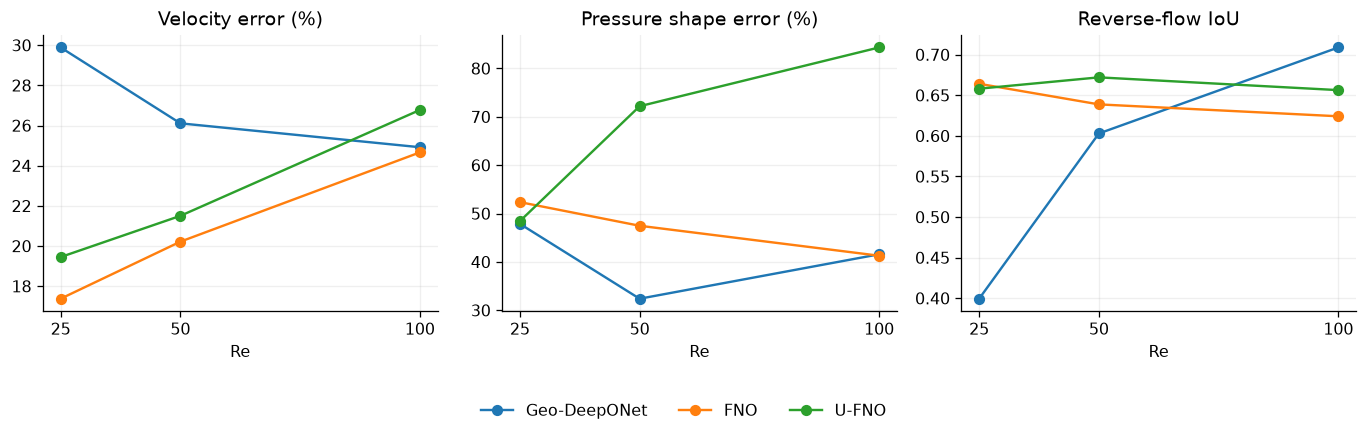

In [7]:
fig,axs = plt.subplots(1,3,figsize=(12,3.8))
for ax,col,title in zip(axs,['velocity_L2_pct','pressure_centered_L2_pct','reverse_IoU'],
                       ['Velocity error (%)','Pressure shape error (%)','Reverse-flow IoU']):
    for m in MODELS:
        d = metrics[metrics.model==LABELS[m]].sort_values('Re')
        ax.plot(d.Re,d[col],'-o',label=LABELS[m])
    ax.set(title=title,xlabel='Re',xticks=RES); ax.grid(alpha=.2)
fig.legend(*axs[0].get_legend_handles_labels(),loc='lower center',ncol=3,frameon=False)
fig.tight_layout(rect=(0,.12,1,1))
fig.savefig(OUT/'metric_comparison.png',bbox_inches='tight'); plt.show()

## 6. Field comparisons — same color scale, actual velocity streamlines

For each Reynolds number, rows are CFD, Geo, FNO and U-FNO. Columns show speed,
mean-removed pressure (stored units), and interior vorticity. Streamlines use each
row's own velocity. Gray areas are solid or excluded derivative stencils, not zero-valued fluid.
The red contour is $u=0$, the boundary of reverse flow, **not a vortex-core detector**.
These are sampled 60×300 fields, not necessarily the original CFD mesh resolution.

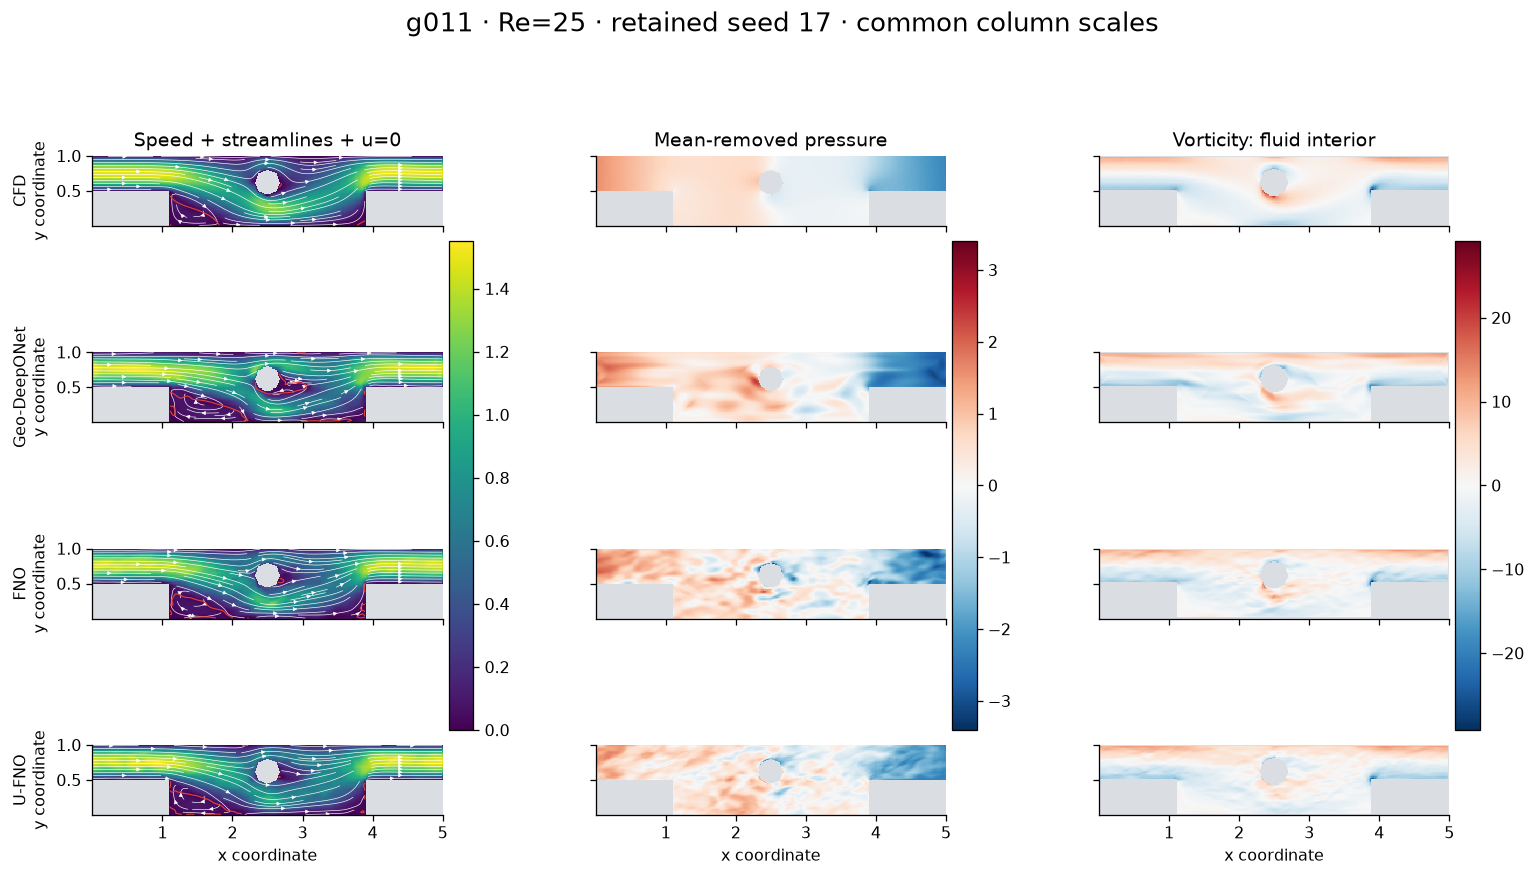

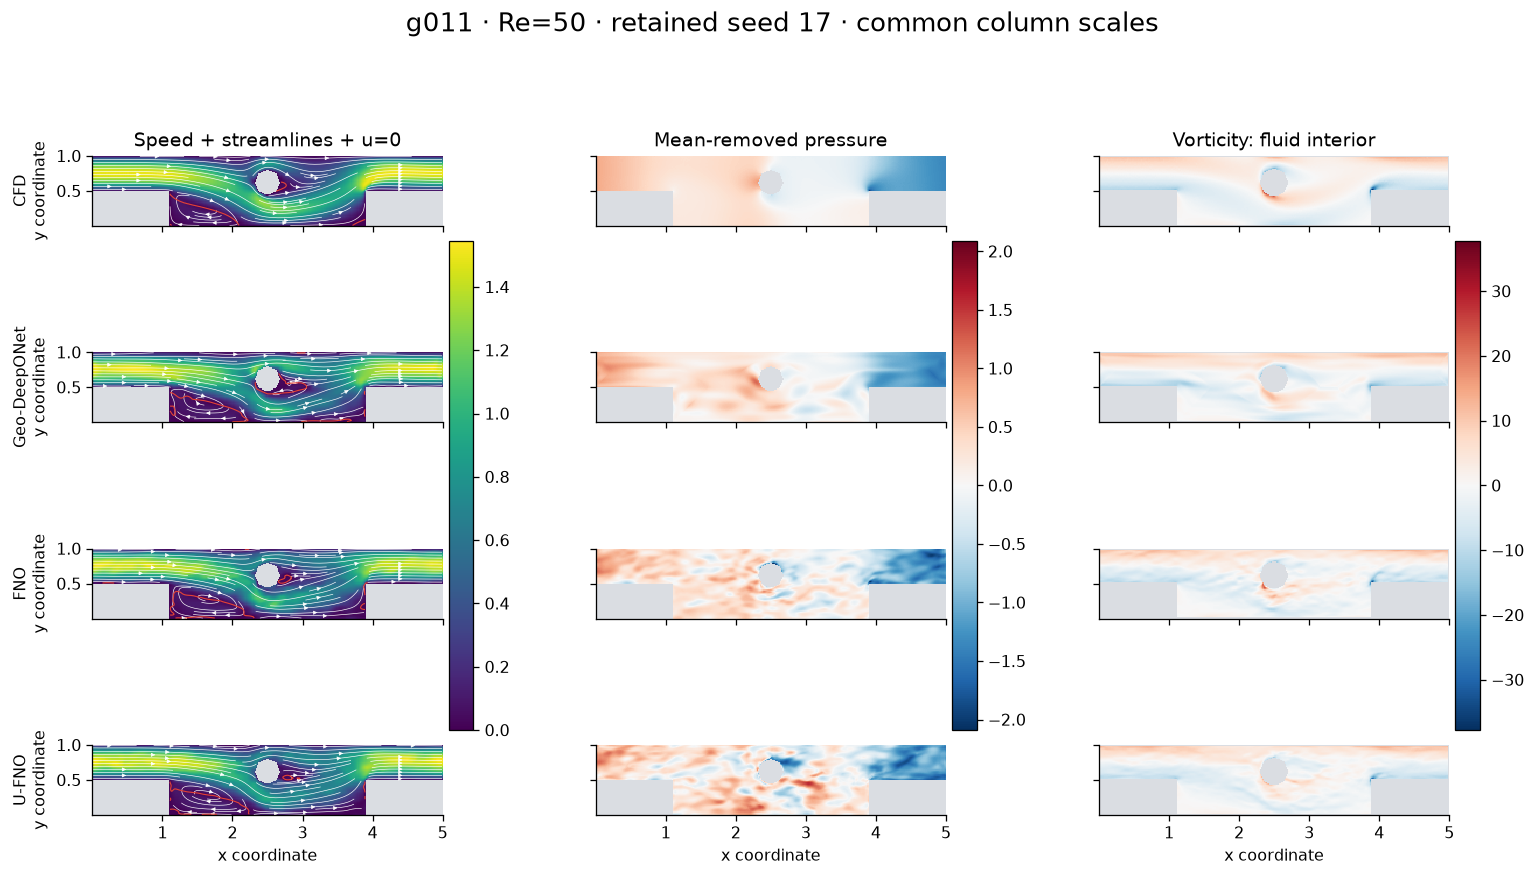

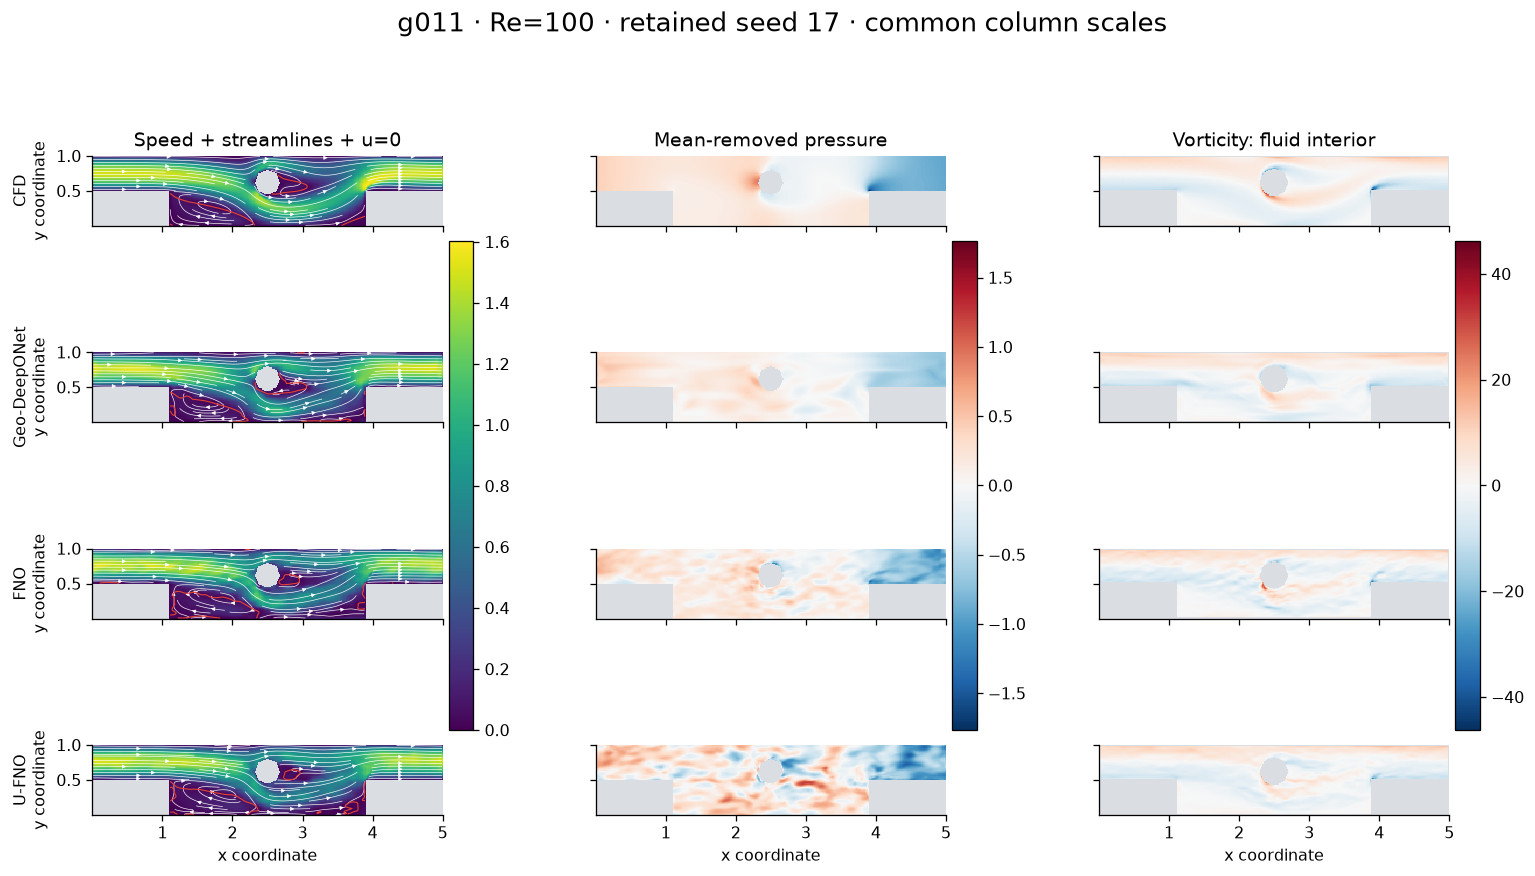

In [8]:
def compare_fields(re):
    f = fields['geom',re]; x,y,mask = grid(f)
    interior = binary_erosion(mask,structure=np.ones((3,3)),border_value=0)
    arrays = [f['truth']] + [fields[m,re]['prediction'] for m in MODELS]
    arrays = [a.reshape(*mask.shape,3).astype(float) for a in arrays]
    derived=[]
    for a in arrays:
        speed=np.hypot(a[:,:,0],a[:,:,1])
        pressure=a[:,:,2]-a[:,:,2][mask].mean()
        derived.append([np.ma.masked_where(~mask,speed),
                        np.ma.masked_where(~mask,pressure),
                        np.ma.masked_where(~interior,curl(a,x,y))])
    limits=[max(float(v[0].max()) for v in derived)]
    limits += [max(float(np.abs(v[j]).max()) for v in derived) for j in [1,2]]
    fig,axs=plt.subplots(4,3,figsize=(16,8.5),sharex=True,sharey=True)
    for i,(a,vals,label) in enumerate(zip(arrays,derived,['CFD']+[LABELS[m] for m in MODELS])):
        for j,ax in enumerate(axs[i]):
            cm=plt.get_cmap('viridis' if j==0 else 'RdBu_r').copy(); cm.set_bad('#dadde2')
            im=ax.pcolormesh(x,y,vals[j],shading='nearest',cmap=cm,
                            vmin=0 if j==0 else -limits[j],vmax=limits[j])
            if j==0:
                # linspace avoids roundoff in stored coordinates triggering streamplot's uniformity check.
                ax.streamplot(np.linspace(x[0],x[-1],len(x)),np.linspace(y[0],y[-1],len(y)),
                    np.ma.masked_where(~mask,a[:,:,0]),np.ma.masked_where(~mask,a[:,:,1]),
                    color='white',density=.8,linewidth=.4,arrowsize=.5)
                ax.contour(x,y,np.ma.masked_where(~mask,a[:,:,0]),levels=[0],colors=['#e34336'],linewidths=.7)
            ax.set_aspect('equal'); ax.set_facecolor('#dadde2')
            if i==0: ax.set_title(['Speed + streamlines + u=0','Mean-removed pressure','Vorticity: fluid interior'][j])
            if j==0: ax.set_ylabel(label+'\ny coordinate')
            if i==3: ax.set_xlabel('x coordinate')
            if i==0: fig.colorbar(im,ax=axs[:,j],shrink=.65,pad=.015)
    fig.suptitle(f'g011 · Re={re} · retained seed 17 · common column scales',fontsize=16)
    fig.savefig(OUT/f'fields_Re{re}.png',dpi=150,bbox_inches='tight'); plt.show()

for re in RES: compare_fields(re)

## 7. Local error: global averages can hide separation failure
Below, choose a Reynolds number without selecting a 'best' model. Error scales are
shared across the three models; the right-hand profiles are taken at the nearest
sampled coordinate to x=3.0. This coordinate is a diagnostic choice, not a measured
reattachment location.

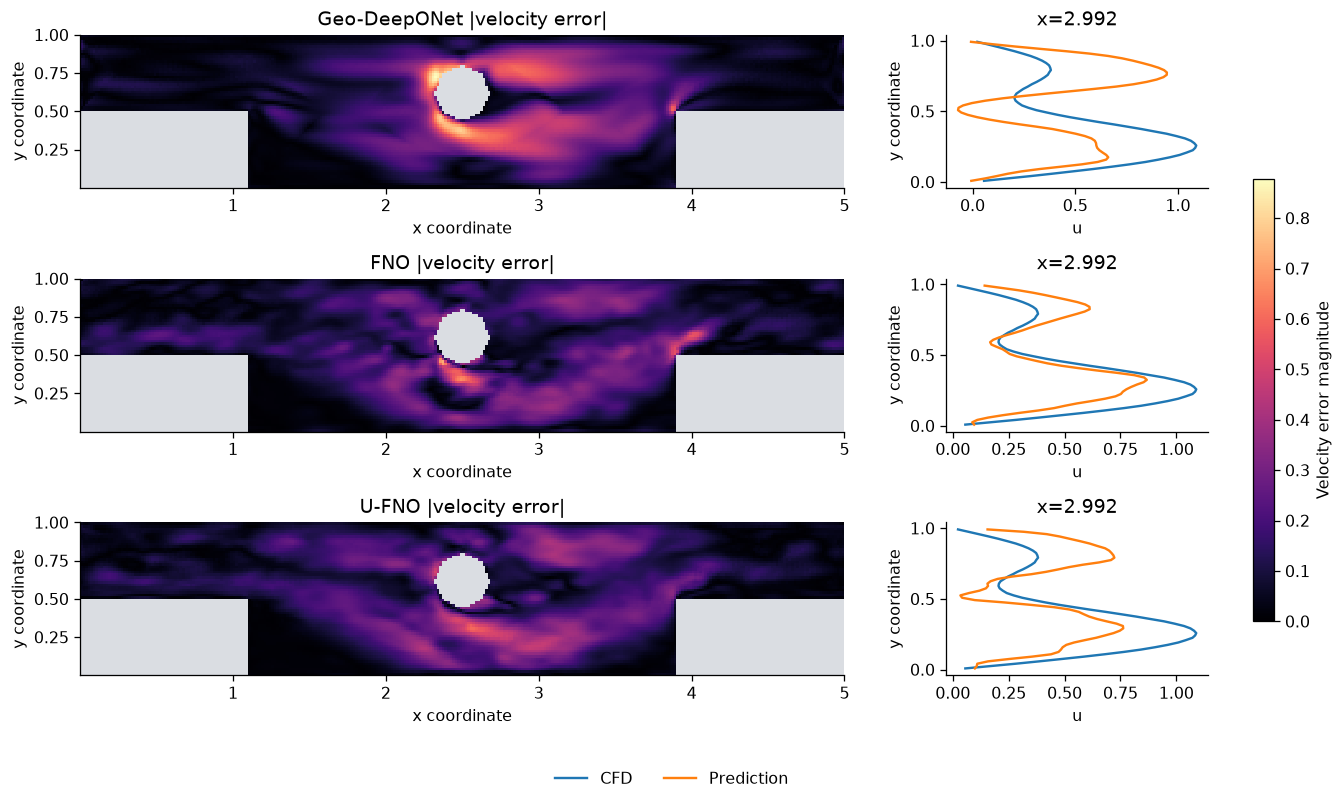

In [9]:
RE_VIEW = 50
f=fields['geom',RE_VIEW]; x,y,mask=grid(f)
t=f['truth'].reshape(*mask.shape,3)
errors=[np.ma.masked_where(~mask,np.linalg.norm(fields[m,RE_VIEW]['prediction'].reshape(*mask.shape,3)[:,:,:2]-t[:,:,:2],axis=2)) for m in MODELS]
vmax=max(float(e.max()) for e in errors)
fig,axs=plt.subplots(3,2,figsize=(12,7),gridspec_kw={'width_ratios':[3,1]})
ix=int(np.argmin(abs(x-3.0)))
for i,m in enumerate(MODELS):
    im=axs[i,0].pcolormesh(x,y,errors[i],cmap='magma',vmin=0,vmax=vmax,shading='nearest')
    axs[i,0].set(title=LABELS[m]+' |velocity error|',xlabel='x coordinate',ylabel='y coordinate',aspect='equal',facecolor='#dadde2')
    p=fields[m,RE_VIEW]['prediction'].reshape(*mask.shape,3)
    axs[i,1].plot(np.ma.masked_where(~mask[:,ix],t[:,ix,0]),y,label='CFD')
    axs[i,1].plot(np.ma.masked_where(~mask[:,ix],p[:,ix,0]),y,label='Prediction')
    axs[i,1].set(xlabel='u',ylabel='y coordinate',title=f'x={x[ix]:.3f}')
fig.tight_layout(rect=(0,.07,.9,1))
cax=fig.add_axes([.92,.22,.015,.55]); fig.colorbar(im,cax=cax,label='Velocity error magnitude')
fig.legend(*axs[0,1].get_legend_handles_labels(),loc='lower center',ncol=2,frameon=False)
fig.savefig(OUT/'local_errors.png',dpi=150,bbox_inches='tight'); plt.show()

## 8. Research progression — do not mix experiments

The source conversation reports subsequent Geo/FNO experiments, including a
combined pressure-gradient/reverse-flow loss and broader geometry/family splits.
Those **later raw predictions are not in this archive**. Consequently this notebook
does not graph their quoted scores as independently verified measurements and does
not combine their three-seed results with this older single-seed comparison.

**Audit finding:** reverse-flow IoU recomputed with the explicit u<0/all-fluid rule
does not exactly match the saved report. The source does not document its threshold
or region. Both values and their difference are retained; we do not tune a threshold
to manufacture agreement or claim the original IoU was reproduced.

The older raw pressure metric can look much smaller than mean-removed pressure
error. Both are valid questions with different denominators. Report them together,
state the reference convention, and inspect spatial errors before claiming success.

### A controlled extension of the step case
1. Inventory all geometries, Reynolds numbers, solver settings and data hashes.
2. Freeze two separate splits: whole geometries within known families, then a whole
   unseen family (e.g. double-step). All Reynolds numbers of one geometry stay together.
3. Fit all scalers on training fields only; fix the pressure convention. Geometry/SDF,
   coordinates and Re may be inputs; reference velocity and target-derived wake masks may not.
4. Keep Geo, FNO and U-FNO on identical splits; report parameter counts, optimizer
   updates and time rather than calling unequal architectures 'identical cost'.
5. Compare field loss, pressure-gradient loss, reverse-flow weighting, and their
   combination. Choose weights/checkpoints on validation, never the examined test fields.
6. Repeat with seeds 17, 29, 43; report per-case scores, mean/std, worst cases and failures.
7. Validate CFD convergence, grid/time sensitivity, flux balance and a suitable
   independent step benchmark before interpreting learned fields as physical truth.

### Student submission
Explain whether model ranking changes between velocity, pressure and reverse flow.
Why is a low raw-pressure percentage insufficient? Why is u<0 IoU not vortex-center
accuracy? Which cells were excluded from vorticity? Propose one genuinely unopened
geometry test, and list the files needed to reproduce training (source at recorded
hash, environment, split/scalers, checkpoints, histories and reference-solver records).

### Provenance
- Author-provided `wake_predictions.tgz`, SHA256 verified in cell 1; training protocol
  `wake_focused_geometry_holdout`. Individual member hashes and complete source
  metadata are exported to `generated/source_manifest.json`.
- Original run identifier reported in the conversation: `64302321` (not independently
  checked against the scheduler here).
- Source discussion: [بررسی وضعیت ران‌ها](https://chatgpt.com/g/g-p-6a9cb70bca088191b3c56cff0bf4ffe4-jyw-dyp-nt-w-stp/c/6aa31405-950c-83e9-b04d-be4c383ca09f).
- This is a teaching audit of the author's artifacts, not a replication of an external
  Geo-DeepONet paper or a claim of a new architecture. No new license for upstream data
  or code is assigned by this notebook. Do not publish the private conversation itself.

## 9. The project's ordinary DeepONet — code and retained V5 evidence

The project already contains an ordinary DeepONet implementation in
`qa/step_architecture_v5.py`; omitting it would be misleading. Its branch receives
only normalized step height, its trunk receives normalized `(x,y)`, and a rank-48
inner product returns two velocity components. The exact project architecture is:

- two 128-wide `tanh` layers in the branch and trunk;
- branch projection to 48 latent coefficients;
- trunk projection to `48 × 2` spatial coefficients; and
- an operator contraction producing `(u,v)`.

That V5 experiment concerns the author's **rarefied DSMC height family**, not the
continuum 130-case OpenFOAM archive below. It is nevertheless direct evidence for
the requested lesson: ordinary DeepONet had 14.01%/23.31% terminal global error for
uniform/zonal sampling and 190.44%/93.41% vortex-region error, and no seed met the
predeclared checkpoint ceiling. Geo-DeepONet-uniform produced eligible checkpoints
for all three seeds. We keep the studies separate instead of attaching DSMC scores
to OpenFOAM contours.

def build_model(tf, geom, kind, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    if kind == 'geom':
        return geom.build_step_geom_deeponet(width=48, omega_0=10, seed=seed)
    keras = tf.keras
    if kind == 'mlp':
        x = keras.Input(shape=(None, 8), name='known_geometry_features')
        z = keras.layers.Dense(48, activation='tanh')(x)
        z = keras.layers.Dense(48, activation='tanh')(z)
        return keras.Model(x, keras.layers.Dense(2)(z), name='coordinate_mlp')
    branch = keras.Input(shape=(1,), name='height_ratio')
    query = keras.Input(shape=(None, 2), name='normalized_xy')
    b, t = branch, query
    for width in (128, 128):
        b = keras.layers.Dense(width, activation='tanh')(b)
        t = keras.layers.Dense(width, activation='tanh')(t)
    b = keras.layers.Dense(48)(b)
    t = keras.layers.Dense(96)(t)
    _, _, contraction = geom._keras_components()
    return keras.Model((branch, query), contraction(rank=48, 

terminal_global_percent  terminal_vortex_percent
model    sampler                                                  
deeponet uniform                   14.006                  190.441
         zonal                     23.308                   93.411
geom     uniform                   10.521                  104.321
         zonal                     36.832                  106.344
mlp      uniform                    6.861                  108.398
         zonal                     10.286                   44.310

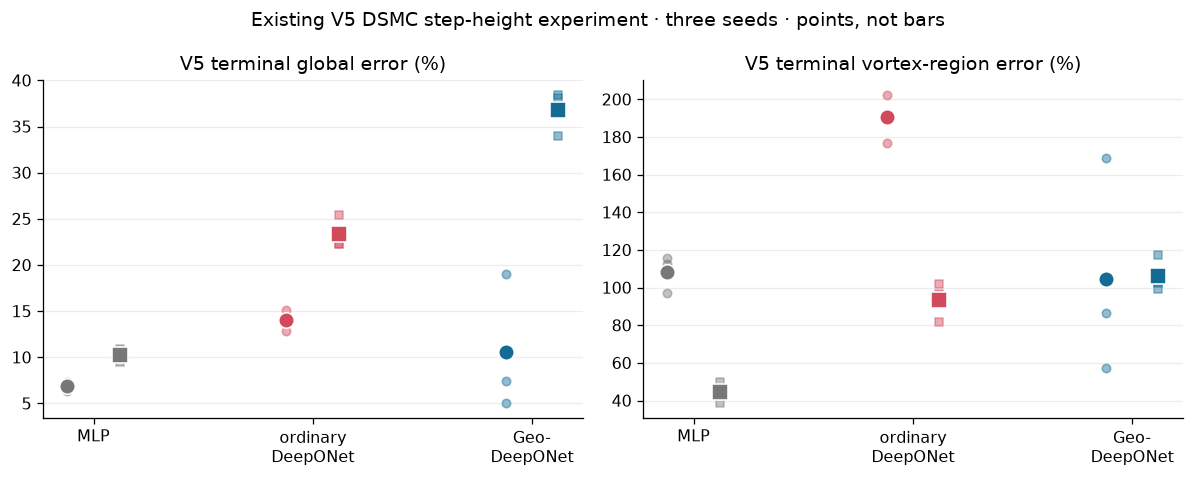

PASS: exact project builder located; ordinary-DeepONet contract and all 18 V5 records verified.


In [10]:
import ast, textwrap
V5_SOURCE = ARCHIVE.parents[1].parent / 'qa/step_architecture_v5.py'
V5_METRICS = ARCHIVE.parents[1].parent / 'results/step_architecture_v5/seed_metrics.csv'
source_text=V5_SOURCE.read_text(encoding='utf-8')
tree=ast.parse(source_text)
node=next(n for n in tree.body if isinstance(n,ast.FunctionDef) and n.name=='build_model')
project_build_model=ast.get_source_segment(source_text,node)
assert "name='vanilla_deeponet'" in project_build_model
assert "for width in (128, 128)" in project_build_model
assert "contraction(rank=48, output_dim=2)" in project_build_model
print(project_build_model)

def numpy_operator_contraction(branch_latent,trunk_latent,rank=48,output_dim=2):
    # Dependency-free shape/value test of the project's branch-trunk contraction.
    b=np.asarray(branch_latent,float)
    t=np.asarray(trunk_latent,float).reshape(*np.asarray(trunk_latent).shape[:-1],output_dim,rank)
    return np.einsum('...r,...qor->...qo',b,t)

rng=np.random.default_rng(15)
b=rng.normal(size=(4,48)); t=rng.normal(size=(4,137,96))
y=numpy_operator_contraction(b,t)
assert y.shape==(4,137,2) and np.isfinite(y).all()
v5=pd.read_csv(V5_METRICS)
assert set(v5.model)=={'mlp','deeponet','geom'} and set(v5.seed)=={690,691,692}
display(v5.groupby(['model','sampler'])[['terminal_global_percent','terminal_vortex_percent']].mean().round(3))

fig,axs=plt.subplots(1,2,figsize=(10.5,4.2))
for ax,col,title in zip(axs,['terminal_global_percent','terminal_vortex_percent'],
                       ['V5 terminal global error (%)','V5 terminal vortex-region error (%)']):
    for j,(model,color) in enumerate([('mlp','#777777'),('deeponet','#d1495b'),('geom','#146c94')]):
        for sampler,marker,offset in [('uniform','o',-.12),('zonal','s',.12)]:
            d=v5[(v5.model==model)&(v5.sampler==sampler)][col]
            ax.scatter([j+offset]*len(d),d,s=28,alpha=.45,color=color,marker=marker)
            ax.scatter([j+offset],[d.mean()],s=95,color=color,marker=marker,edgecolor='white',zorder=3)
    ax.set(xticks=range(3),xticklabels=['MLP','ordinary\nDeepONet','Geo-\nDeepONet'],title=title)
    ax.grid(axis='y',alpha=.22)
fig.suptitle('Existing V5 DSMC step-height experiment · three seeds · points, not bars')
fig.tight_layout(); fig.savefig(OUT/'vanilla_deeponet_v5_points.png',dpi=160,bbox_inches='tight'); plt.show()
print('PASS: exact project builder located; ordinary-DeepONet contract and all 18 V5 records verified.')

## 10. Geometry generalization: two genuinely harder protocols

The retained follow-up study uses the same 130 accepted OpenFOAM fields but freezes
two different scientific questions. **Geometry holdout** trains on 107 cases,
validates on 11, and tests 12 cases from four unseen geometries (`g009`, `g023`,
`g036`, `g048`). **Family holdout** trains on 103 cases, validates on 8, and tests
19 cases from an excluded double-step family (`g012`, `g045`–`g051`; availability
varies by Reynolds number). All Reynolds-number variants of a held-out geometry stay
outside training. The exact test cases are printed from the committed metrics file;
the training/validation *counts* are retained, but their separate identity lists were
not present in the downloaded evidence and are not guessed.

### Operator theory and the geometry problem

A vanilla DeepONet represents an operator through a branch/trunk inner product,

$$\hat q(\xi)=\sum_{k=1}^{p} b_k(a)\,t_k(\xi)+c.$$

If the branch encoding $a$ contains only flow parameters, the learned spatial basis
$t_k$ is tied to the training domain. Changing a wall, obstacle, or topology changes
the valid coordinate set and boundary conditions; ordinary DeepONet therefore has no
automatic geometry equivariance. Geometry-aware DeepONet adds a mask/SDF or another
shape encoding to the operator input, but it still must extrapolate when an entire
shape family is absent.

FNO alternates local channel mixing with learned spectral convolution,

$$v_{l+1}=\sigma\!\left(W_l v_l+\mathcal F^{-1}(R_l\,\mathcal Fv_l)\right).$$

It is efficient on a common grid, but discontinuous masks, pressure gauge/gradients,
and unseen topology are difficult. U-FNO adds a local U-shaped path to the Fourier
blocks. In this repository U-FNO is available only for the older `g011` audit above;
it was **not** evaluated in the two three-seed protocols below. Ordinary DeepONet is
now trained on the same 107/11/12 OpenFOAM geometry-holdout split for three seeds and
400 epochs. Its branch receives Reynolds number only and its trunk receives x/y; mask,
SDF and geometry ID are deliberately withheld. This is the fixed-domain baseline that
tests whether Reynolds interpolation alone transfers to an unseen wall shape.

diverse_geometry_v1 test geometries: g009, g023, g036, g048
             case  Re
g009_Re100_medium 100
 g009_Re25_medium  25
 g009_Re50_medium  50
g023_Re100_medium 100
 g023_Re25_medium  25
 g023_Re50_medium  50
g036_Re100_medium 100
 g036_Re25_medium  25
 g036_Re50_medium  50
g048_Re100_medium 100
 g048_Re25_medium  25
 g048_Re50_medium  50
diverse_family_v1 test geometries: g012, g045, g046, g047, g048, g049, g050, g051
             case  Re
 g012_Re25_medium  25
 g012_Re50_medium  50
g045_Re100_medium 100
 g045_Re25_medium  25
 g045_Re50_medium  50
g046_Re100_medium 100
 g046_Re25_medium  25
 g046_Re50_medium  50
g047_Re100_medium 100
 g047_Re25_medium  25
 g047_Re50_medium  50
g048_Re100_medium 100
 g048_Re25_medium  25
 g048_Re50_medium  50
g049_Re100_medium 100
 g049_Re25_medium  25
 g049_Re50_medium  50
 g050_Re25_medium  25
 g051_Re25_medium  25


,protocol,model,velocity_error,pressure_error,reverse_iou
0,diverse_family_v1,FNO,9.160,255.613,0.578
1,diverse_family_v1,Geo,18.559,74.578,0.410
2,diverse_geometry_v1,FNO,2.534,43.458,0.876
3,diverse_geometry_v1,Geo,4.812,23.533,0.794


,model,protocol,velocity_error,pressure_error,reverse_iou
0,ordinary DeepONet,diverse_geometry_v1,28.96,299.575,0.406


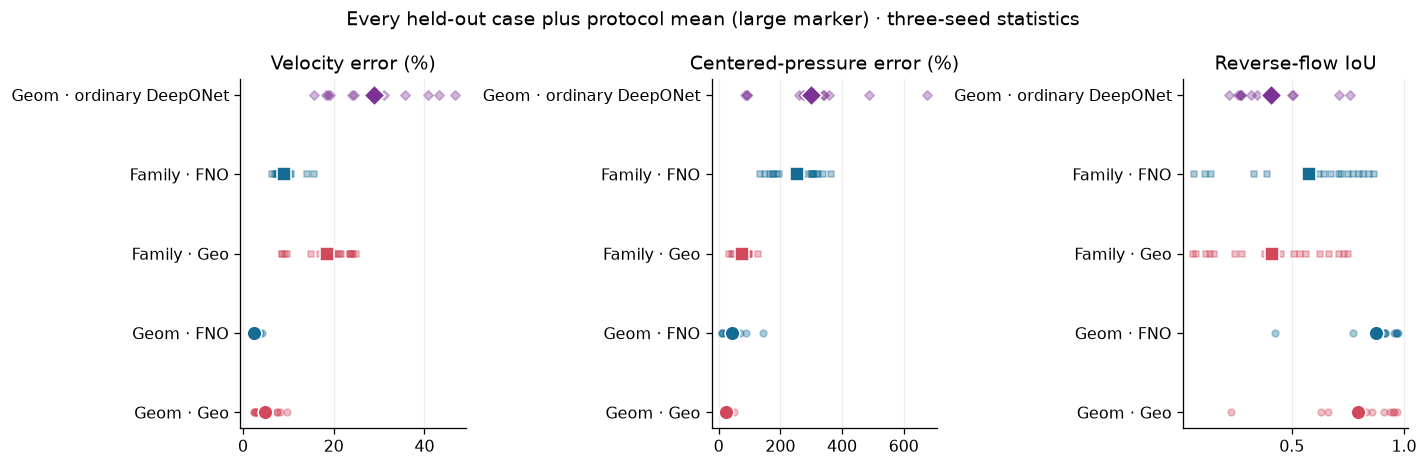

In [11]:
NEW = ARCHIVE.parents[1] / 'step_geometry_generalization'
CASE_METRICS = NEW / 'source/case_metrics.csv'
assert CASE_METRICS.is_file()
diverse = pd.read_csv(CASE_METRICS)
assert set(diverse.protocol)=={'diverse_geometry_v1','diverse_family_v1'}
assert set(diverse.model)=={'Geo','FNO'} and set(diverse.nseed)=={3}
expected_test={'diverse_geometry_v1':{'g009','g023','g036','g048'},
               'diverse_family_v1':{'g012','g045','g046','g047','g048','g049','g050','g051'}}
for protocol, geoms in expected_test.items():
    got=set(diverse.loc[diverse.protocol==protocol,'geometry'])
    assert got==geoms,(protocol,got)
    print(protocol, 'test geometries:', ', '.join(sorted(got)))
    print(diverse.loc[(diverse.protocol==protocol)&(diverse.model=='Geo'),
          ['case','Re']].sort_values(['case']).to_string(index=False))

summary3=(diverse.groupby(['protocol','model'])
          .agg(velocity_error=('velocity_mean','mean'),pressure_error=('pressure_mean','mean'),
               reverse_iou=('reverse_iou_mean','mean')).reset_index())
display(summary3.round(3))

DEEP_ROOT = ARCHIVE.parents[1] / 'week15_ordinary_deeponet'
deep_files=sorted(DEEP_ROOT.glob('ordinary-deeponet-seed*/case_metrics.csv'))
assert len(deep_files)==3,deep_files
deep=pd.concat([pd.read_csv(path) for path in deep_files],ignore_index=True)
assert set(deep.seed)=={17,29,43} and len(deep)==36
deep_summary=(deep.groupby(['case','geometry','Re'])
              .agg(velocity_mean=('velocity_percent','mean'),
                   velocity_std=('velocity_percent','std'),
                   pressure_mean=('pressure_percent','mean'),
                   pressure_std=('pressure_percent','std'),
                   reverse_iou_mean=('reverse_iou','mean')).reset_index())
display(pd.DataFrame([{'model':'ordinary DeepONet','protocol':'diverse_geometry_v1',
    'velocity_error':deep.velocity_percent.mean(),'pressure_error':deep.pressure_percent.mean(),
    'reverse_iou':deep.reverse_iou.mean()}]).round(3))

# Point/range plots only: no bars.
fig,axs=plt.subplots(1,3,figsize=(12.5,4.1))
for ax,(metric,title) in zip(axs,[('velocity_mean','Velocity error (%)'),
                                  ('pressure_mean','Centered-pressure error (%)'),
                                  ('reverse_iou_mean','Reverse-flow IoU')]):
    ypos=0
    for protocol,marker in [('diverse_geometry_v1','o'),('diverse_family_v1','s')]:
        for model,color in [('Geo','#d1495b'),('FNO','#146c94')]:
            d=diverse[(diverse.protocol==protocol)&(diverse.model==model)][metric]
            ax.scatter(d,[ypos]*len(d),s=18,alpha=.35,color=color,marker=marker)
            ax.scatter([d.mean()],[ypos],s=85,color=color,marker=marker,edgecolor='white',zorder=3)
            ypos+=1
    d=deep_summary[{'velocity_mean':'velocity_mean','pressure_mean':'pressure_mean',
                    'reverse_iou_mean':'reverse_iou_mean'}[metric]]
    ax.scatter(d,[4]*len(d),s=18,alpha=.35,color='#7b3294',marker='D')
    ax.scatter([d.mean()],[4],s=85,color='#7b3294',marker='D',edgecolor='white',zorder=3)
    ax.set(title=title,yticks=range(5),yticklabels=['Geom · Geo','Geom · FNO','Family · Geo','Family · FNO','Geom · ordinary DeepONet'])
    ax.grid(axis='x',alpha=.22)
fig.suptitle('Every held-out case plus protocol mean (large marker) · three-seed statistics')
fig.tight_layout(); fig.savefig(NEW/'generated/generalization_case_points.png',dpi=160,bbox_inches='tight'); plt.show()

## 11. CFD beside neural predictions — velocity, streamlines, and pressure

First read the experiment from left to right: several distinct development
geometries, an unseen geometry withheld from fitting, and four fields on that
same unseen geometry. The blue thumbnails below are **confirmed training**
examples for the newly trained ordinary DeepONet. The historical Geo-DeepONet
and FNO runs retain test identities and counts, but not separate train-versus-
validation identity lists; we do not claim that every blue thumbnail was in
their training subset. The test geometry g009 is excluded from both training
and validation in this geometry-holdout protocol.

Each case below uses a common column scale. Rows are CFD, ordinary DeepONet,
Geo-DeepONet, and FNO;
columns are speed with the row's own streamlines, then independently mean-removed
pressure. These are raw seed-17 fields from the held-out geometry protocol—not
interpolated screenshots. Each model row reports its velocity and centered-pressure
relative L2 errors against the CFD row. The first case makes the ordinary DeepONet's
substantially larger error visible as both a number and a field discrepancy; the
second exposes the crucial trade-off: a plausible velocity field can coexist with a
very poor pressure field. The committed PDF casebooks contain all 12 geometry-holdout
and all 19 family-holdout test cases in the same row-wise format.

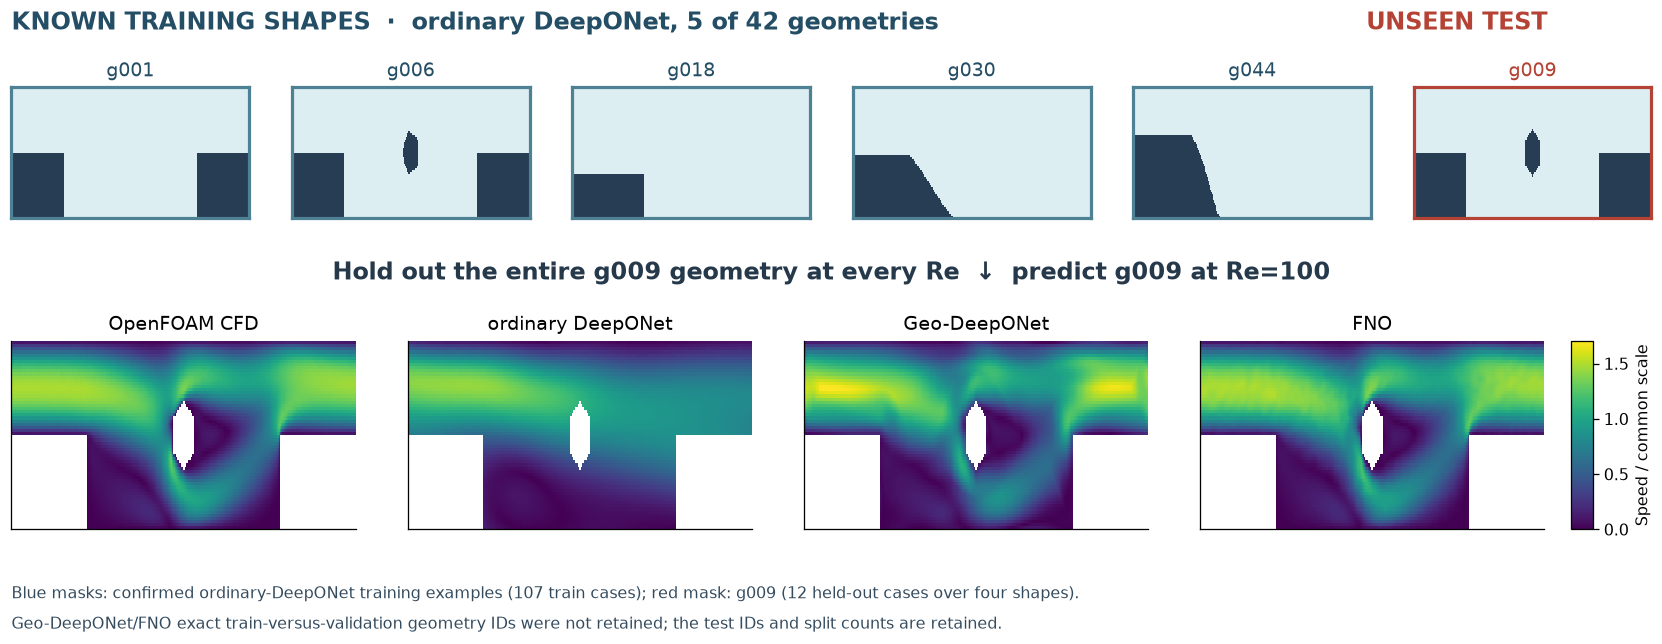

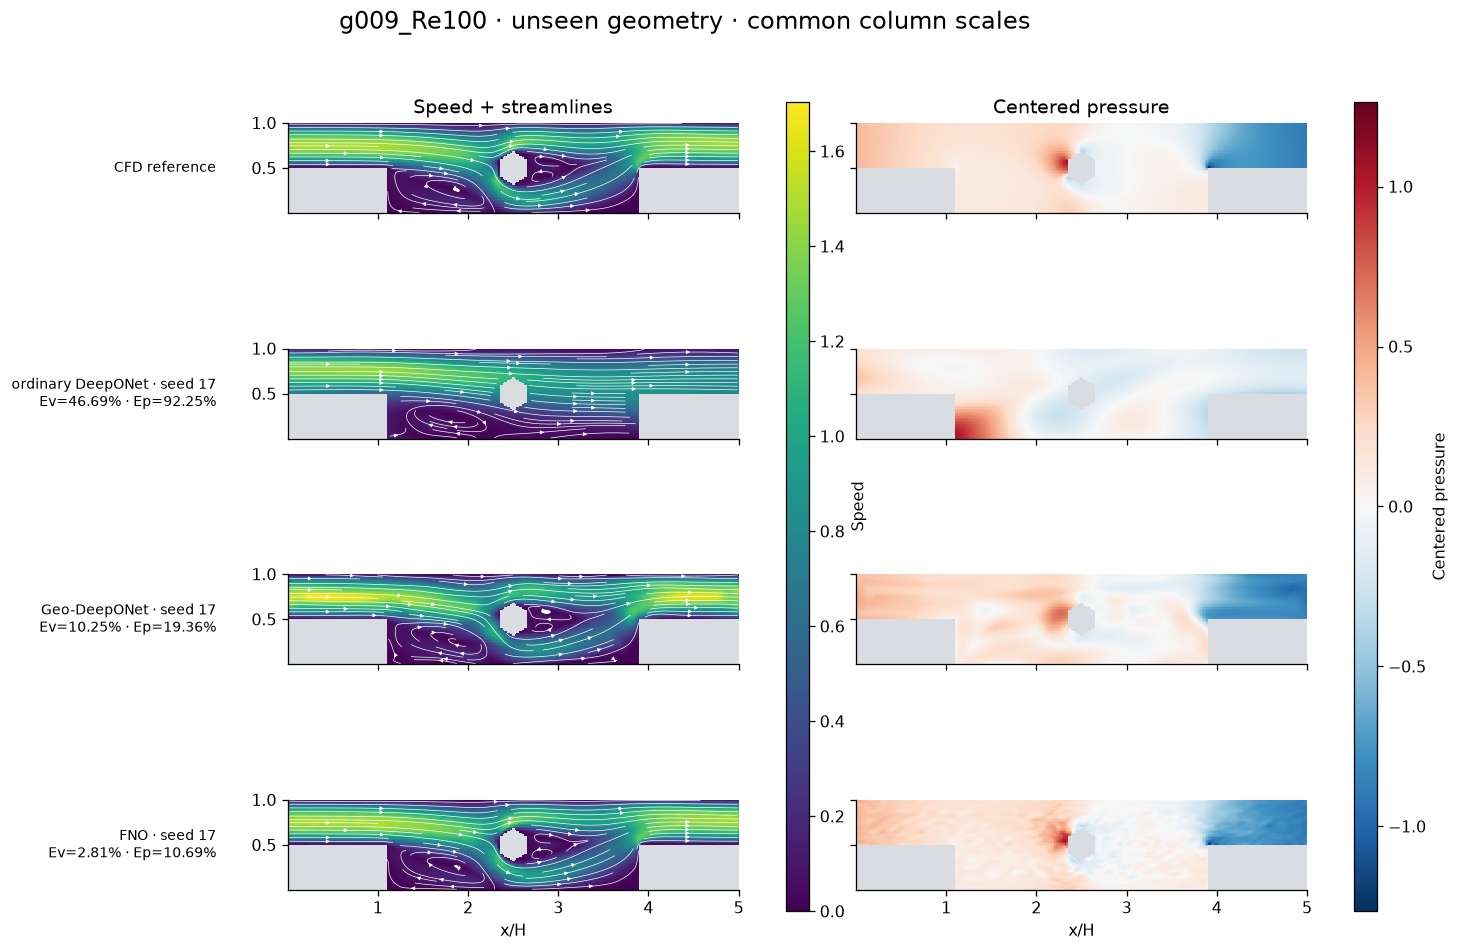

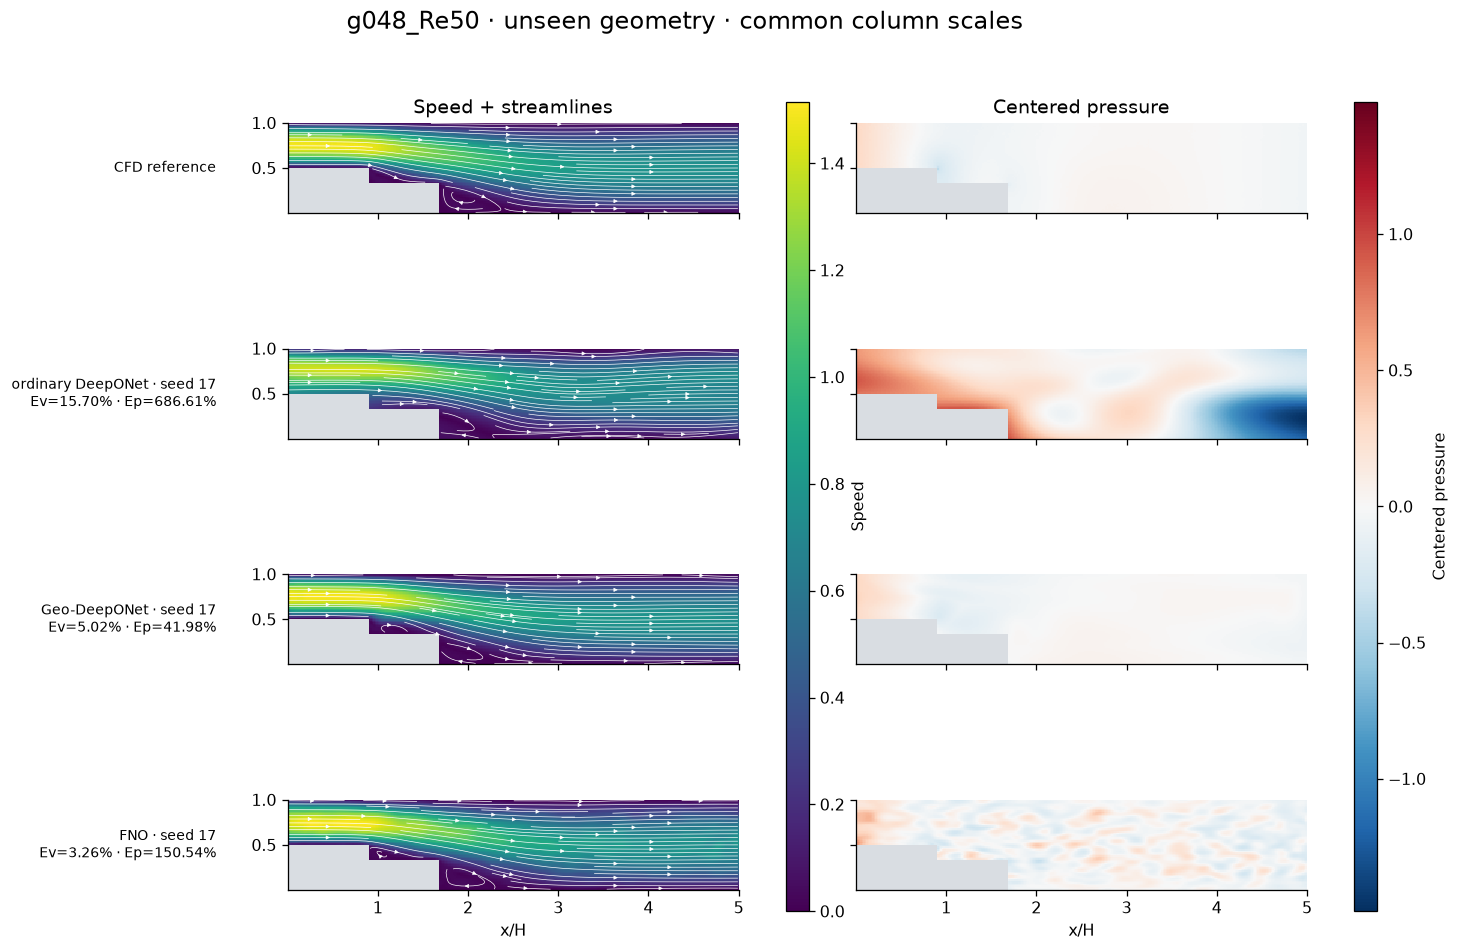

In [12]:
def load_followup(case,model):
    path=NEW/f'source/predictions/geometry_holdout/{model}/seed_17/{case}_prediction.npz'
    with np.load(path,allow_pickle=False) as z: return {k:z[k].copy() for k in z.files}

def load_ordinary(case):
    path=DEEP_ROOT/f'ordinary-deeponet-seed17/predictions/geometry_holdout/ordinary_deeponet/seed_17/{case}_prediction.npz'
    with np.load(path,allow_pickle=False) as z: return {k:z[k].copy() for k in z.files}

def geometry_generalization_overview():
    case='g009_Re100_medium'
    geo=load_followup(case,'geo_deeponet')
    ordinary=load_ordinary(case)
    fno=load_followup(case,'fno')
    train_examples=[1,6,18,30,44]
    recorded=json.loads((DEEP_ROOT/'ordinary-deeponet-seed17/manifest.json').read_text())['split']
    forbidden=set(recorded['validation_geometry_ids']+recorded['test_geometry_ids'])
    assert not (set(train_examples)&forbidden)
    assert recorded['test_geometry_ids']==[9,23,36,48]
    assert (recorded['train_cases'],recorded['validation_cases'],recorded['test_cases'])==(107,11,12)
    fig=plt.figure(figsize=(15.5,6.3),facecolor='white')
    top=fig.add_gridspec(1,6,left=.04,right=.96,top=.80,bottom=.62,wspace=.18)
    from matplotlib.colors import ListedColormap
    mask_cmap=ListedColormap(['#263d53','#dceef1'])
    for j,gid in enumerate(train_examples+[9]):
        idx=int(np.flatnonzero(geometry_ids==gid)[0])
        mask=dataset['masks'][idx].reshape(60,300)
        ax=fig.add_subplot(top[0,j])
        ax.imshow(mask,origin='lower',extent=(0,5,0,1),aspect='auto',
                  cmap=mask_cmap,vmin=0,vmax=1,interpolation='nearest')
        ax.set(xticks=[],yticks=[],xlim=(0,5),ylim=(0,1))
        ax.set_title(f'g{gid:03d}',fontsize=12,color='#b44235' if gid==9 else '#244e65',pad=7)
        for spine in ax.spines.values():
            spine.set_visible(True); spine.set_color('#b44235' if gid==9 else '#4f8194'); spine.set_linewidth(2)
    np.testing.assert_array_equal(dataset['masks'][np.flatnonzero(geometry_ids==9)[0]],geo['mask'])
    fig.text(.04,.88,'KNOWN TRAINING SHAPES  ·  ordinary DeepONet, 5 of 42 geometries',
             fontsize=15,weight='bold',color='#244e65')
    fig.text(.80,.88,'UNSEEN TEST',fontsize=15,weight='bold',color='#b44235')
    fig.text(.5,.535,'Hold out the entire g009 geometry at every Re  ↓  predict g009 at Re=100',
             ha='center',fontsize=15,weight='bold',color='#25394b')
    bottom=fig.add_gridspec(1,4,left=.04,right=.90,top=.45,bottom=.19,wspace=.15)
    ny,nx=map(int,geo['shape']); mask=geo['mask'].reshape(ny,nx)
    outputs=[('OpenFOAM CFD',geo['truth']),('ordinary DeepONet',ordinary['prediction']),
             ('Geo-DeepONet',geo['prediction']),('FNO',fno['prediction'])]
    vmax=max(float(np.hypot(a.reshape(ny,nx,3)[:,:,0],a.reshape(ny,nx,3)[:,:,1])[mask].max())
             for _,a in outputs)
    for j,(name,array) in enumerate(outputs):
        a=array.reshape(ny,nx,3)
        speed=np.ma.masked_where(~mask,np.hypot(a[:,:,0],a[:,:,1]))
        ax=fig.add_subplot(bottom[0,j])
        im=ax.imshow(speed,origin='lower',extent=(0,5,0,1),aspect='auto',
                     cmap='viridis',vmin=0,vmax=vmax,interpolation='nearest')
        ax.set(xticks=[],yticks=[],xlim=(0,5),ylim=(0,1))
        ax.set_title(name,fontsize=12,pad=7)
    fig.colorbar(im,cax=fig.add_axes([.915,.19,.012,.26]),label='Speed / common scale')
    fig.text(.04,.095,'Blue masks: confirmed ordinary-DeepONet training examples (107 train cases); red mask: g009 (12 held-out cases over four shapes).',
             fontsize=10,color='#344b5e')
    fig.text(.04,.053,'Geo-DeepONet/FNO exact train-versus-validation geometry IDs were not retained; the test IDs and split counts are retained.',
             fontsize=10,color='#344b5e')
    fig.savefig(NEW/'generated/geometry_train_to_unseen_test.png',dpi=165,bbox_inches='tight')
    plt.show()

geometry_generalization_overview()

def geometry_comparison(case):
    fs=[load_followup(case,'geo_deeponet'),load_ordinary(case),load_followup(case,'geo_deeponet'),load_followup(case,'fno')]
    arr=[fs[0]['truth'],fs[1]['prediction'],fs[2]['prediction'],fs[3]['prediction']]
    ny,nx=map(int,fs[0]['shape']); xy=fs[0]['coordinates'].reshape(ny,nx,2)
    x,y=xy[0,:,0],xy[:,0,1]; mask=fs[0]['mask'].reshape(ny,nx)
    aa=[a.reshape(ny,nx,3).astype(float) for a in arr]
    speed=[np.ma.masked_where(~mask,np.hypot(a[:,:,0],a[:,:,1])) for a in aa]
    pressure=[np.ma.masked_where(~mask,a[:,:,2]-a[:,:,2][mask].mean()) for a in aa]
    truth=aa[0]
    labels=['CFD reference']
    for name,pred in zip(['ordinary DeepONet','Geo-DeepONet','FNO'],aa[1:]):
        ev=100*np.linalg.norm((pred[:,:,:2]-truth[:,:,:2])[mask])/np.linalg.norm(truth[:,:,:2][mask])
        pp=pred[:,:,2][mask]-pred[:,:,2][mask].mean()
        pt=truth[:,:,2][mask]-truth[:,:,2][mask].mean()
        ep=100*np.linalg.norm(pp-pt)/np.linalg.norm(pt)
        labels.append(f'{name} · seed 17\nEv={ev:.2f}% · Ep={ep:.2f}%')
    vmax=max(float(v.max()) for v in speed); plim=max(float(np.abs(v).max()) for v in pressure)
    fig=plt.figure(figsize=(12.8,8.8))
    grid=fig.add_gridspec(4,4,left=.23,right=.97,top=.89,bottom=.09,
                          width_ratios=[20,1,20,1],wspace=.20,hspace=.70)
    axs=np.empty((4,2),dtype=object)
    for row in range(4):
        for col,grid_col in enumerate((0,2)):
            axs[row,col]=fig.add_subplot(grid[row,grid_col],
                sharex=axs[0,0] if row or col else None,
                sharey=axs[0,0] if row or col else None)
    for i,(a,label) in enumerate(zip(aa,labels)):
        im0=axs[i,0].pcolormesh(x,y,speed[i],cmap='viridis',vmin=0,vmax=vmax,shading='nearest')
        axs[i,0].streamplot(np.linspace(x[0],x[-1],len(x)),np.linspace(y[0],y[-1],len(y)),
          np.ma.masked_where(~mask,a[:,:,0]),np.ma.masked_where(~mask,a[:,:,1]),
          color='white',density=.85,linewidth=.42,arrowsize=.5)
        im1=axs[i,1].pcolormesh(x,y,pressure[i],cmap='RdBu_r',vmin=-plim,vmax=plim,shading='nearest')
        axs[i,0].set_ylabel(label,rotation=0,ha='right',va='center',labelpad=22,fontsize=9)
        for ax in axs[i]: ax.set_aspect('equal'); ax.set_facecolor('#d9dde2')
        axs[i,1].tick_params(axis='y',labelleft=False)
        if i<3:
            for ax in axs[i]: ax.tick_params(axis='x',labelbottom=False)
    axs[0,0].set_title('Speed + streamlines'); axs[0,1].set_title('Centered pressure')
    for ax in axs[-1]: ax.set_xlabel('x/H')
    fig.colorbar(im0,cax=fig.add_subplot(grid[:,1]),label='Speed')
    fig.colorbar(im1,cax=fig.add_subplot(grid[:,3]),label='Centered pressure')
    fig.suptitle(case.replace('_medium','')+' · unseen geometry · common column scales',fontsize=15)
    fig.savefig(NEW/f'generated/{case}_fields.png',dpi=165,bbox_inches='tight'); plt.show()

for case in ['g009_Re100_medium','g048_Re50_medium']: geometry_comparison(case)

## 12. What the tests actually establish

For unseen geometries within represented families, mean velocity error is about
4.81% for Geo-DeepONet and 2.53% for FNO, but centered-pressure error reverses the
story (23.53% versus 43.46%). Holding out the whole double-step family is much harder:
mean velocity errors rise to 18.56% and 9.16%, pressure errors to 74.58% and 255.61%,
and reverse-flow IoU falls to 0.410 and 0.578. Case-level seed spread is also large
for Geo-DeepONet in several family tests.

The defensible conclusion is therefore not “FNO wins.” It is that neither model has
demonstrated reliable topology extrapolation, velocity ranking does not determine
pressure ranking, and a fixed-domain or incompletely conditioned DeepONet cannot be
trusted under geometry change merely because it interpolates Reynolds number well.
Use the casebooks to inspect every failure; do not summarize this experiment with one
bar height.

The new fixed-domain ordinary DeepONet makes that limitation directly measurable on
the same 12 OpenFOAM geometry-holdout cases: three-seed mean velocity error is 28.96%,
centered-pressure error is 299.57%, and reverse-flow IoU is 0.406. At g009/Re100 its
three velocity errors span only 46.61–47.14%, so the failure is repeatable rather than
a single unlucky initialization.

### References

- Lu et al. (2021), *Learning nonlinear operators via DeepONet based on the universal approximation theorem of operators*, Nature Machine Intelligence 3, 218–229.
- Li et al. (2021), *Fourier Neural Operator for Parametric Partial Differential Equations*, ICLR.
- Li et al. (2022), *Fourier Neural Operator with Learned Deformations for PDEs on General Geometries*, arXiv:2207.05209.

In [13]:
summary={'status':'passed', 'mode':'dataset_and_retained_prediction_audit_not_training',
    'archive_sha256':EXPECTED_SHA,'dataset_sha256':EXPECTED_DATASET_SHA,
    'dataset_cases':130,'dataset_geometries':51,'split_cases':{'train':106,'validation':21,'test':3},
    'predictions':len(fields),'prediction_geometries':1,'seeds':[17],
    'Re':RES,'source_metric_checks':18,'diagnostic_tests':4,'dataset_checks':9,
    'source_discrepancies':['reverse-flow IoU: source threshold/region undocumented'],
    'ordinary_deeponet_source':'qa/step_architecture_v5.py',
    'ordinary_deeponet_v5_records':int(len(v5)),
    'ordinary_deeponet_openfoam_records':int(len(deep)),
    'followup_protocols':['diverse_geometry_v1','diverse_family_v1'],
    'followup_test_cases':int(diverse[['protocol','case']].drop_duplicates().shape[0]),
    'followup_seeds':[17,29,43],
    'missing':['Geo-DeepONet/FNO training source','checkpoints','complete OpenFOAM case directories'],
    'numpy':np.__version__,'python':platform.python_version()}
(OUT/'execution_summary.json').write_text(json.dumps(summary,indent=2),encoding='utf-8')
display(pd.DataFrame([summary]).drop(columns=['missing']))
print('Audit complete. Outputs:',OUT)

,status,mode,archive_sha256,dataset_sha256,dataset_cases,dataset_geometries,split_cases,predictions,prediction_geometries,seeds,...,dataset_checks,source_discrepancies,ordinary_deeponet_source,ordinary_deeponet_v5_records,ordinary_deeponet_openfoam_records,followup_protocols,followup_test_cases,followup_seeds,numpy,python
0,passed,dataset_and_retained_prediction_audit_not_trai...,190bb252c2739fc2acfa0841233652144b82eb9ca3a01a...,28d4d4c440cdc4c1ac1d13749ce00b0690d99f29cf20fd...,130,51,"{'train': 106, 'validation': 21, 'test': 3}",9,1,[17],...,9,[reverse-flow IoU: source threshold/region und...,qa/step_architecture_v5.py,18,36,"[diverse_geometry_v1, diverse_family_v1]",31,"[17, 29, 43]",2.5.3,3.12.14


Audit complete. Outputs: C:\Users\roohie\OneDrive - University of Massachusetts\Documents\ChatGPT\FlowMLLAB\.release-week13-15\results\step_operator_audit\generated
